In [23]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.fft as fft
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import timm

import os
import time

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# -------------------------------
# 1. Configuration
# -------------------------------
IMAGENET_DIR = ""
SAVE_PATH = "zero/"
SAVE_ALL = "all_spectra/"
BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_BATCHES = 2000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("cpu")
SEED = 42

import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HTTP_TIMEOUT'] = '120' 


In [3]:
def ploting_image(feats, image):
    L = len(feats)
    fig, axes = plt.subplots(1, L+1, figsize=(30, 10))
    axes[0].imshow(np.mean(image[-1].numpy(), axis=0), cmap='gray')
    for i, (name, feat) in enumerate(feats.items()):
        feat = feat[-1].squeeze(0).mean(dim=2)
        axes[i+1].imshow(feat.cpu().numpy(), cmap='viridis')
        axes[i+1].set_title(f"Канал {i}")
        axes[i+1].axis('off')
    plt.show()

## Сохранненные спектры открыть

In [24]:
spectra_swin_tiny = np.load(f'{SAVE_PATH}swin_tiny.npz', allow_pickle=True)
spectra_swin_small = np.load(f'{SAVE_PATH}swin_small.npz', allow_pickle=True)
spectra_swin_base = np.load(f'{SAVE_PATH}swin_base.npz', allow_pickle=True)
spectra_swin_large = np.load(f'{SAVE_PATH}swin_large.npz', allow_pickle=True)

models_dict = {
    "Tiny": spectra_swin_tiny,
    "Small": spectra_swin_small,
    "Base": spectra_swin_base,
    "Large": spectra_swin_large
}
markers = {
    "Tiny": "s",
    "Small": "o",
    "Base": "<",
    "Large": "d"
}

## Функции для извлечения спектров

In [2]:

# -------------------------------
# 2. Reproducibility
# -------------------------------
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(SEED)

# -------------------------------
# 3. ImageNet DataLoader
# -------------------------------
def get_imagenet_val_loader(data_dir, batch_size, num_workers):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize,
    ])
    val_dataset = datasets.ImageFolder(root="imagenet", transform=val_transform)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                             shuffle=False, num_workers=num_workers, pin_memory=True)
    return val_loader

# -------------------------------
# 4. Spectral Analysis Functions
# -------------------------------
def compute_fft_power(feat):
    feat = feat.float()
    F2 = fft.fft2(feat, norm="ortho")
    F2_shift = fft.fftshift(F2, dim=(-2, -1))
    power = torch.abs(F2_shift) ** 2
    power_mean = power.mean(dim=(0, 1))  # [H, W]
    return power_mean.cpu()

def radial_average(power_2d):
    H, W = power_2d.shape
    cy, cx = H // 2, W // 2
    y = np.arange(H) - cy
    x = np.arange(W) - cx
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    R_int = R.astype(np.int32)

    r_max = R_int.max()
    radial_sum = np.zeros(r_max + 1, dtype=np.float64)
    radial_count = np.zeros(r_max + 1, dtype=np.int64)

    power_np = power_2d.numpy()
    for r in range(r_max + 1):
        mask = (R_int == r)
        radial_sum[r] = power_np[mask].sum()
        radial_count[r] = mask.sum()

    radial_mean = np.zeros_like(radial_sum)
    nonzero = radial_count > 0
    radial_mean[nonzero] = radial_sum[nonzero] / radial_count[nonzero]

    s = radial_mean.sum()
    if s > 0:
        radial_mean = radial_mean / s
    return radial_mean

# -------------------------------
# 5. Hooked Model
# -------------------------------
class HookedSwin(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.model.eval()
        self.features = {}

        self.block_resolutions = {}  # key: 'stageX_blockY' -> (H, W)
        block_counter = 0
        total_blocks = sum(len(stage.blocks) for stage in self.model.layers)
        for stage_idx, stage in enumerate(self.model.layers):
            # В timm SwinStage имеет атрибут input_resolution (H, W)
            H, W = stage.input_resolution
            for block_idx, block in enumerate(stage.blocks):
                name = f"stage{stage_idx}_block{block_idx}_total{block_counter}"
                self.block_resolutions[name] = (H, W)
                # if block_counter in [0, total_blocks//4, total_blocks//2, 3*total_blocks//4, total_blocks-1]:
                block.register_forward_hook(self.hook_fn(name))
                block_counter+=1

    def hook_fn(self, name):
            def fn(module, input, output):
                self.features[name] = output.detach()
            return fn

    def forward(self, x):
        self.features = {}
        return self.model(x)

    def get_features(self):
        return self.features

    def patches_to_2d(self,patch_features, resolution):
        
        B, N, D = patch_features.shape
        H, W = resolution
        if N != H * W:
            raise ValueError(f"Number of patches {N} doesn't match grid {H}x{W}={H*W}")
        # Решейп в (B, H, W, D)
        return patch_features.view(B, H, W, D)

# -------------------------------
# 6. Run Spectral Analysis
# -------------------------------
def collect_spectra(model, loader, device, max_batches, image_plot=None):
    model.eval()
    spectra = {}
    processed = 0

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt += 1
            if cnt%40==2: print(f'{cnt} ')
            images = images.to(device)
            _ = model(images) 
            
            feats = model.get_features()
            if image_plot:
                ploting_image(feats, images)
        
            
            for name, feat in feats.items():
                # feat: (B, N, D)
                # Преобразуем в 2D карту (B, H, W, D)
                if feat.dim() == 4:
                    # Уже 2D: (B, H, W, D)
                    feat_2d = feat
                    H, W = feat.shape[1], feat.shape[2]
                else:
                    # 3D: (B, N, D) → преобразуем в 2D
                    resolution = model.block_resolutions[name]
                    feat_2d = model.patches_to_2d(feat, resolution)
                    H, W = resolution
                
                # Вычитаем среднее по пространству (H, W) для каждого канала
                spatial_mean = feat_2d.mean(dim=(1, 2), keepdim=True)  # (B, 1, 1, D)
                feat_centered = feat_2d - spatial_mean
                
                # Меняем форму для compute_fft_power: из (B, H, W, D) в (B, D, H, W)
                # потому что compute_fft_power ожидает (B, C, H, W)
                feat_centered = feat_centered.permute(0, 3, 1, 2)  # (B, D, H, W)
                
                # Считаем спектр (используем ту же функцию, что для ResNet)
                power_2d = compute_fft_power(feat_centered)  # (H, W)
                
                # Радиальное усреднение
                curve = radial_average(power_2d)
                spectra.setdefault(name, []).append(curve)

            if cnt >= max_batches:
                break

    mean_spectra = {}
    for name, curves in spectra.items():
        try:
            min_len = min(c.shape[0] for c in curves)
            aligned = np.stack([c[:min_len] for c in curves], axis=0)
            mean_curve = aligned.mean(axis=0)
            mean_spectra[name] = mean_curve
        except:
            mean_spectra[name] = curves
            print(curves)
        
    return mean_spectra

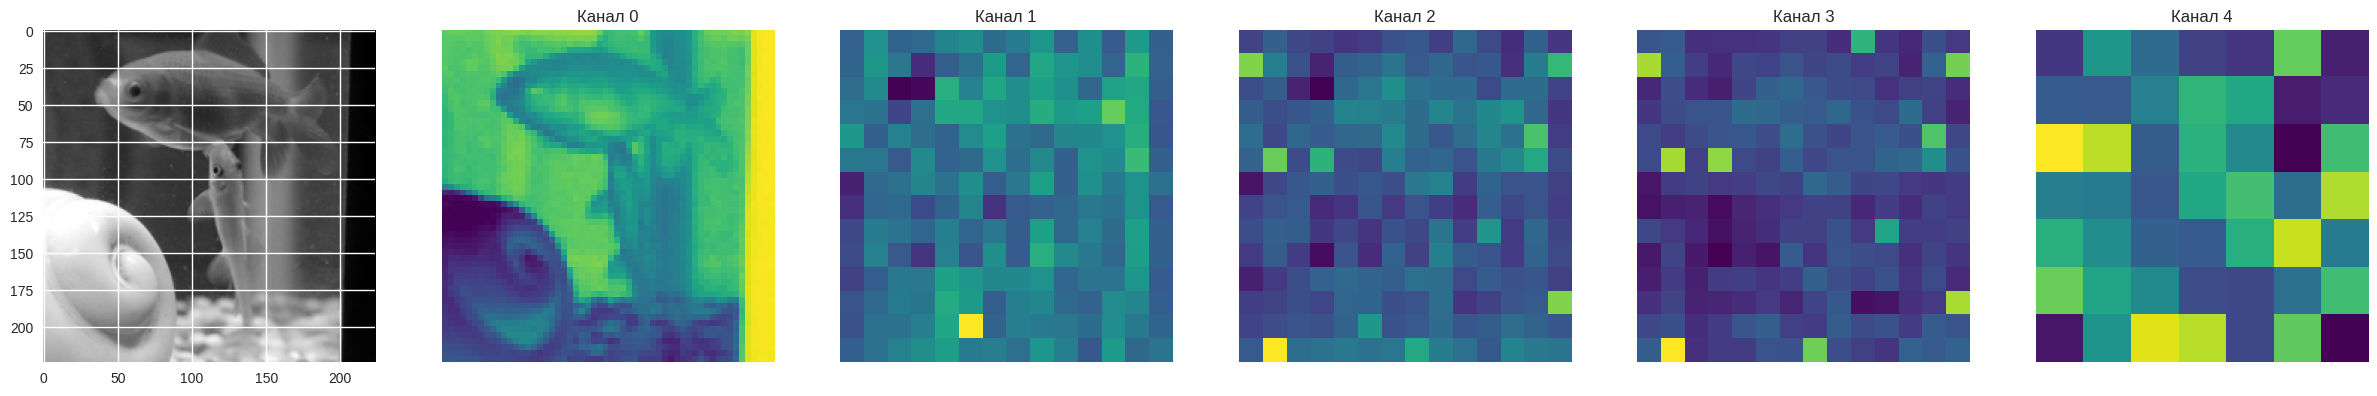

2 


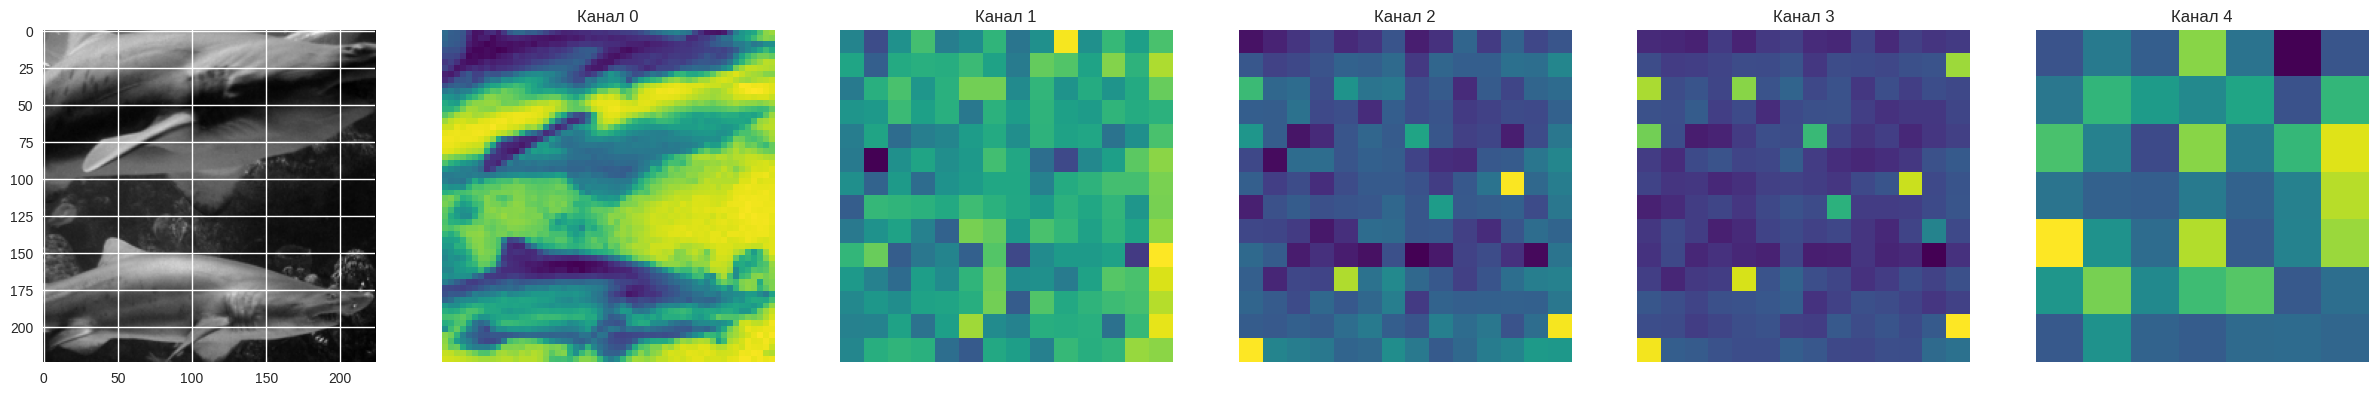

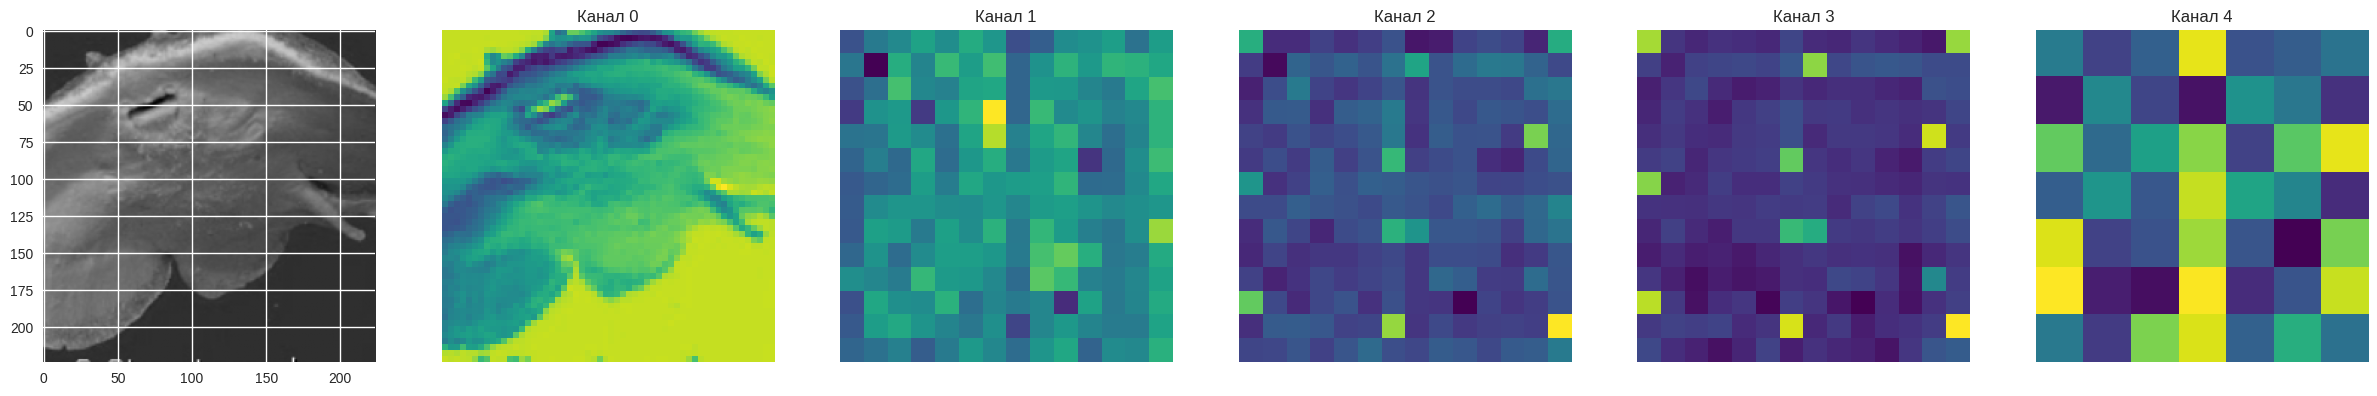

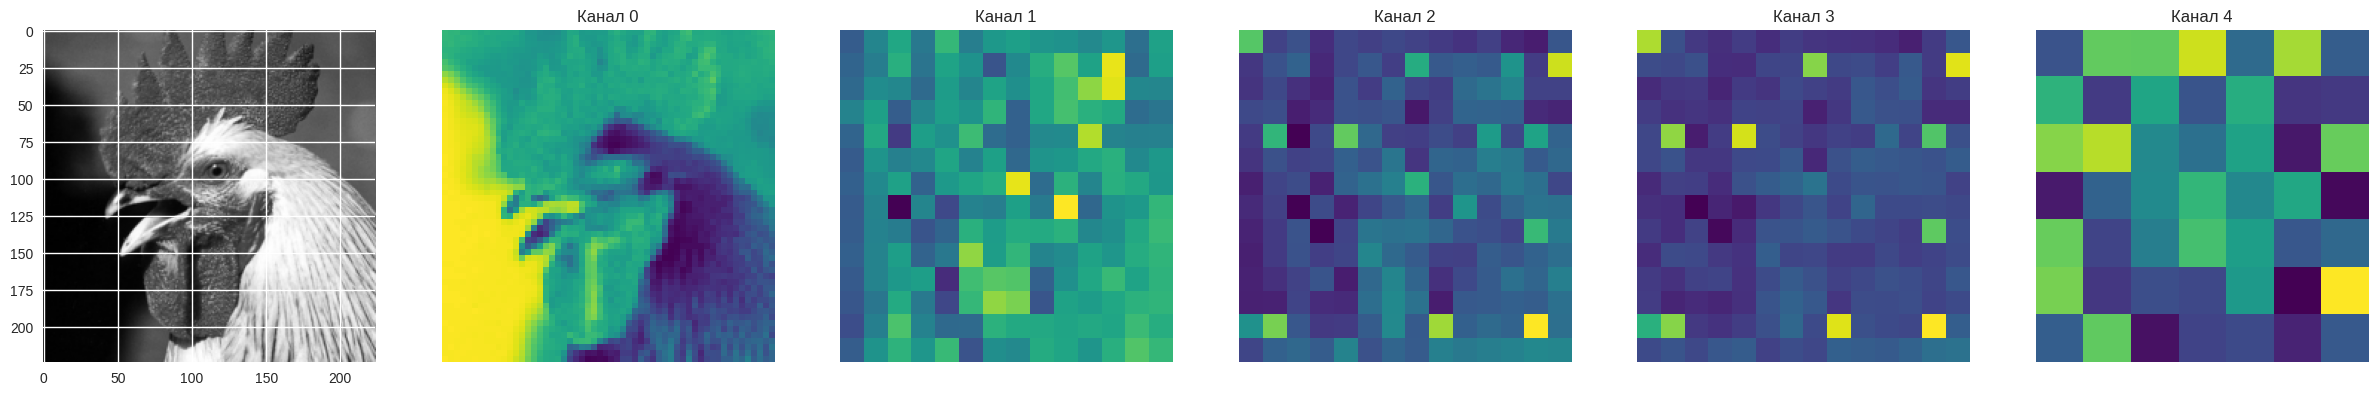

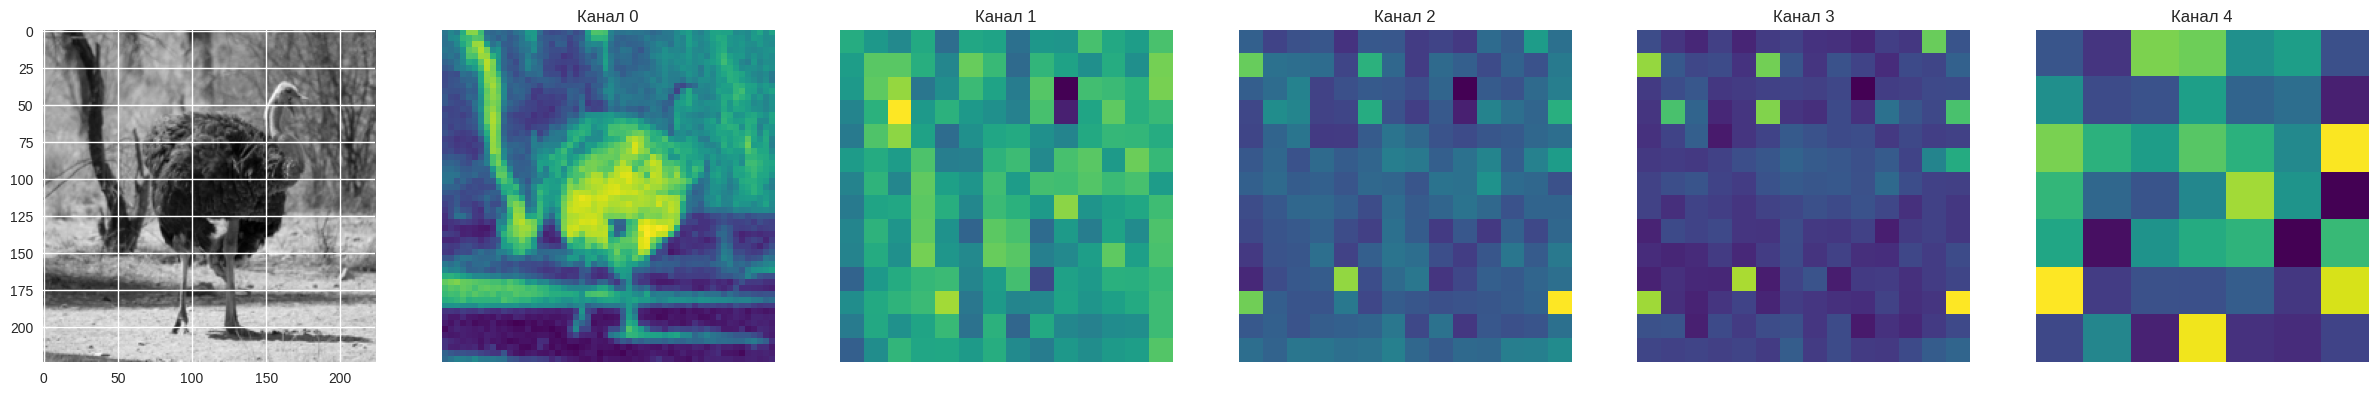

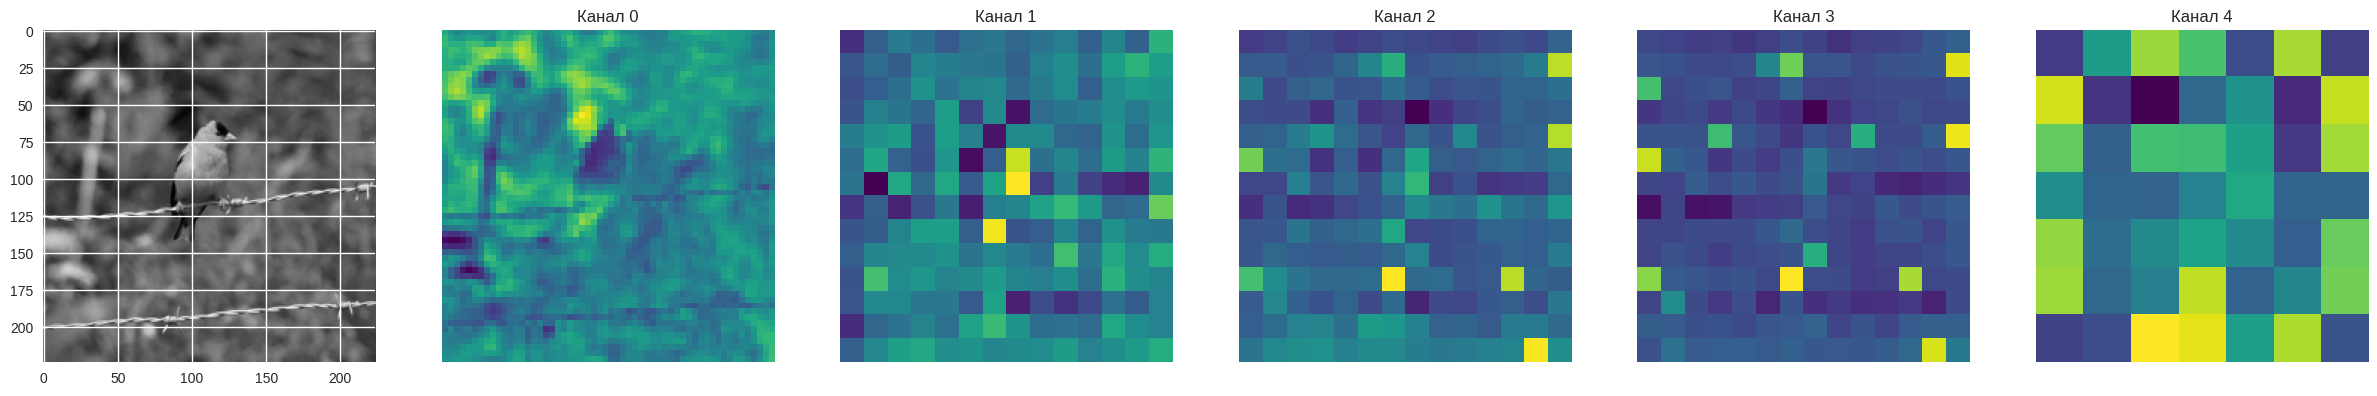

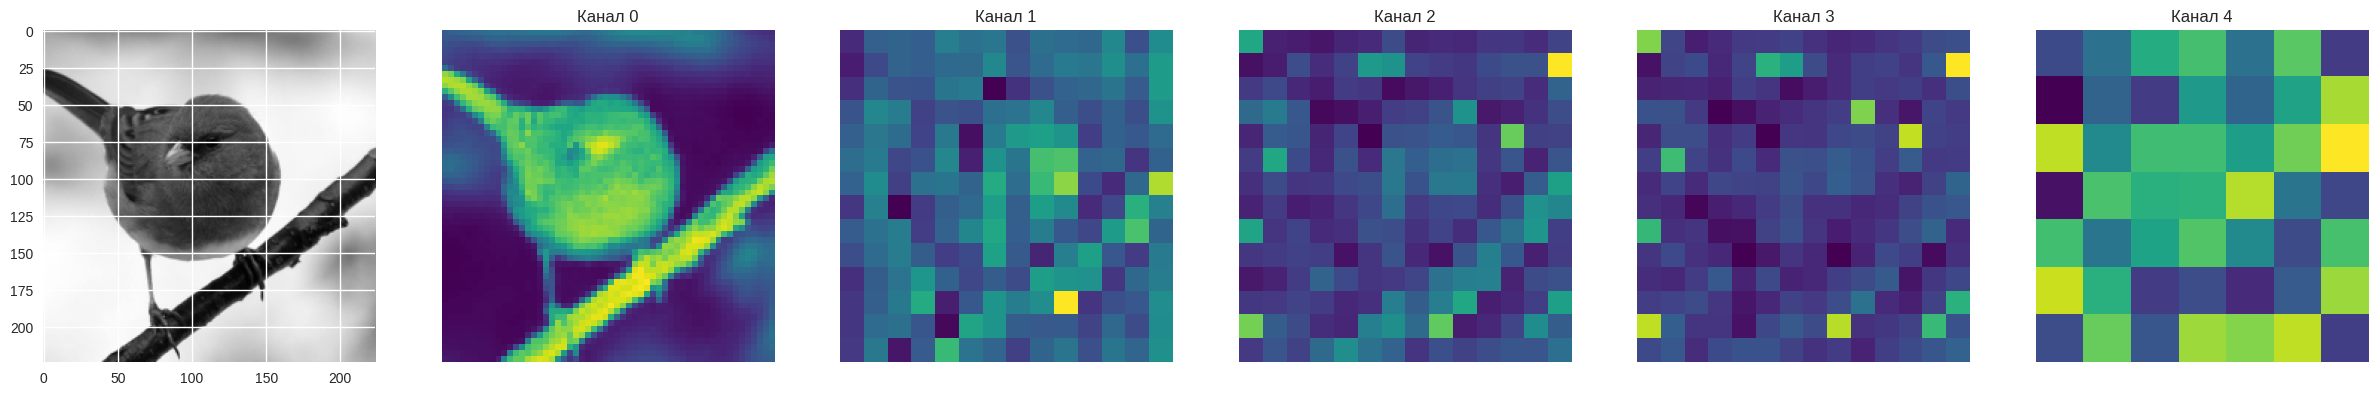

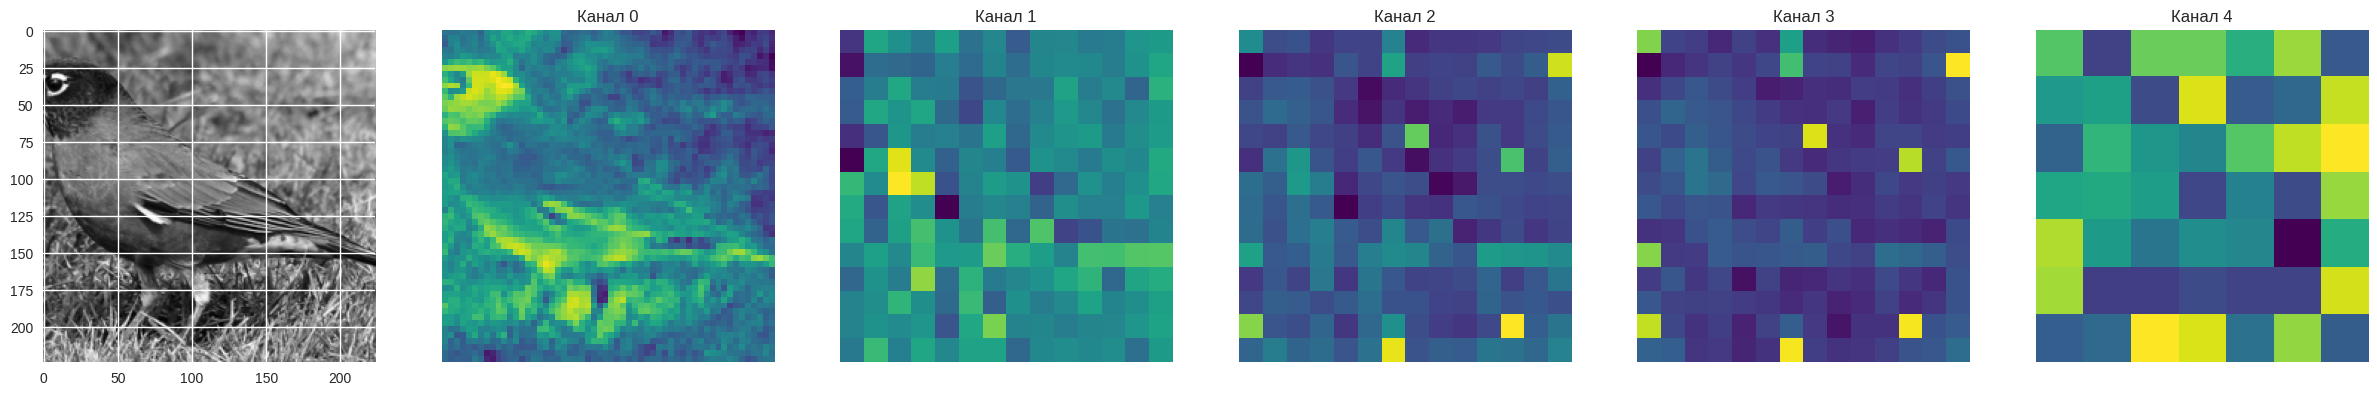

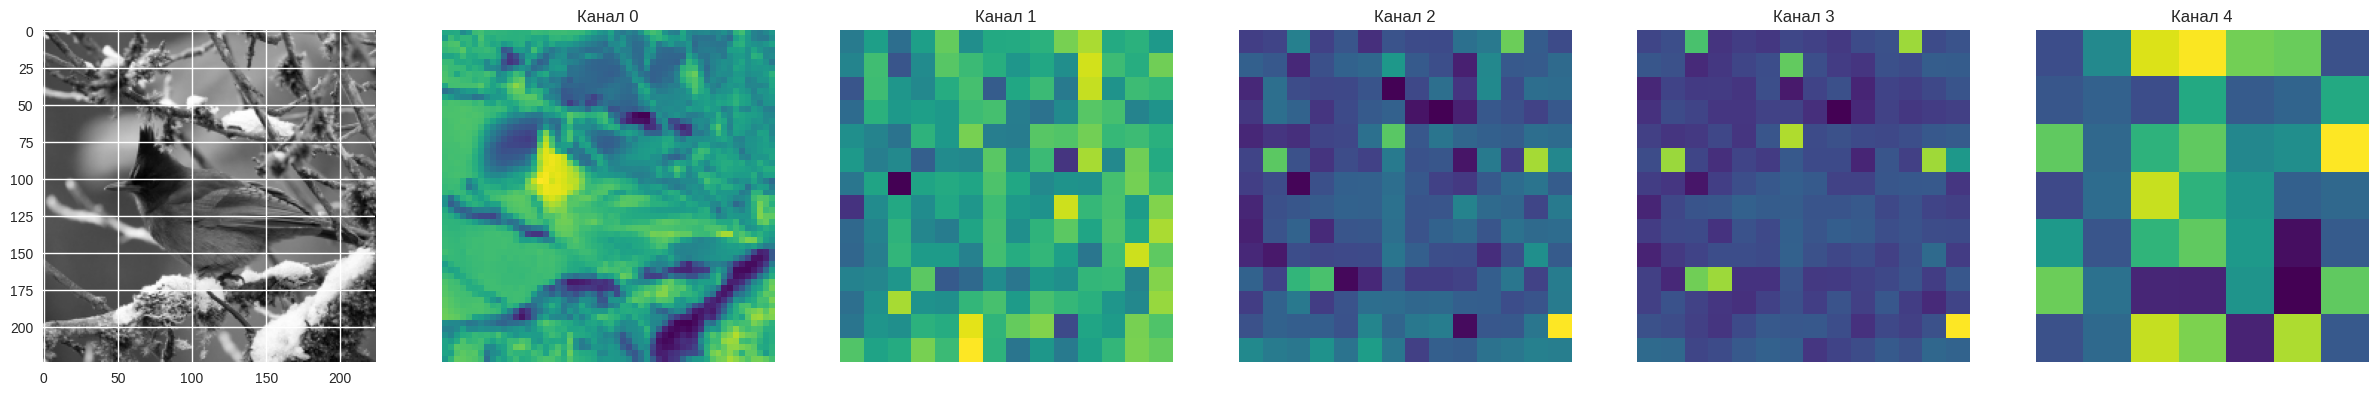

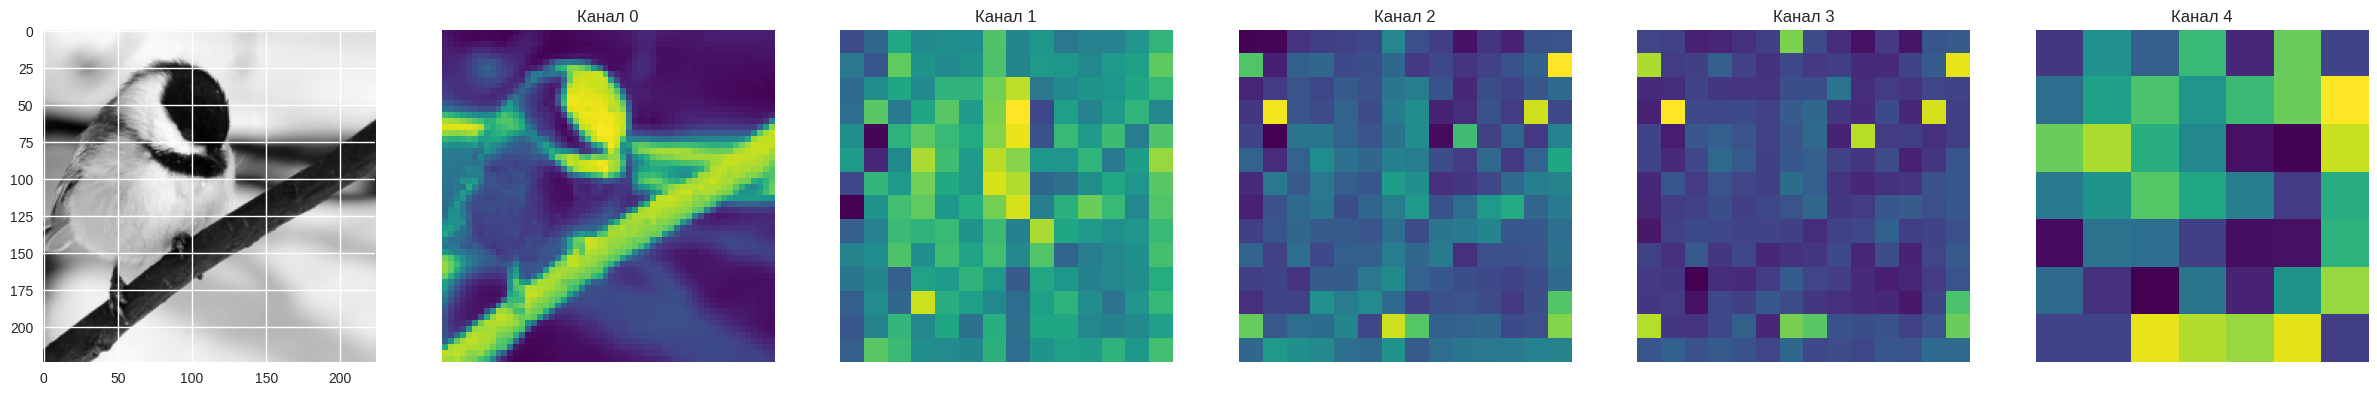

{'stage0_block0_total0': array([1.17964477e-13, 5.73464597e-01, 1.35219602e-01, 6.23928032e-02,
        3.76134905e-02, 2.24242410e-02, 1.66526918e-02, 1.24652945e-02,
        1.01680505e-02, 8.55993806e-03, 7.39934531e-03, 6.77921677e-03,
        6.07787858e-03, 5.50552351e-03, 5.19787481e-03, 4.85412721e-03,
        4.62287608e-03, 4.40571493e-03, 4.22875332e-03, 4.09325122e-03,
        3.96607692e-03, 3.85853454e-03, 3.81989058e-03, 3.72261951e-03,
        3.64314804e-03, 3.60574200e-03, 3.56095965e-03, 3.53445645e-03,
        3.44507833e-03, 3.26892037e-03, 3.23016393e-03, 3.19936662e-03,
        3.18414493e-03, 3.13978546e-03, 3.11706220e-03, 3.14516533e-03,
        3.11449964e-03, 3.11964179e-03, 3.10995503e-03, 3.08951832e-03]),
 'stage2_block2_total6': array([3.88990025e-14, 3.95400373e-01, 1.87803431e-01, 1.03629164e-01,
        8.27300726e-02, 5.80360685e-02, 5.41751070e-02, 4.42764326e-02,
        3.84300486e-02, 3.55193035e-02]),
 'stage2_block8_total12': array([2.92595884e

In [41]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, 20, NUM_WORKERS)
base_small_model = timm.create_model('swin_small_patch4_window7_224', pretrained=True).to(DEVICE)
small_model = HookedSwin(base_small_model).to(DEVICE)
collect_spectra(small_model, val_loader, DEVICE, 10)

## Функции для графиков и метрик

In [25]:
def plot_spectra(spectra_dict, save_path=None):
    plt.style.use("seaborn-v0_8")
    num = len(spectra_dict)
    fig, axs = plt.subplots((num+1)//2, 2, figsize=(12, (1+num)//2*5))
    axs = axs.ravel()
    blocks = sorted(spectra_dict.keys())#, key=lambda x: int(x.split('')[1]))

    for i, blk in enumerate(blocks):
        if blk in spectra_dict:
            curve = spectra_dict[blk]
            x = np.arange(len(curve)) / max(1, (len(curve) - 1))
            axs[i].plot(x, curve, label=blk, color=f"C{i}", linewidth=3)
            axs[i].set_title(f"Спектральная энергия: {blk}", fontsize=25, fontweight='bold', pad=20)
            axs[i].set_xlabel("Нормализованный частотный радиус", fontsize=25, labelpad=20)
            axs[i].set_ylabel("Нормализованная энергия", fontsize=25, labelpad=20)
            axs[i].grid(True)
            axs[i].legend(fontsize=25)

    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

In [26]:
def plot_spectra_compare(model_name, spectra, save_path=None):
    # Spatial resolutions of each layer (used to scale frequency axes)
    resolutions = {layer: len(curve) for layer, curve in spectra.items()}
    
    # Reference resolution (Layer1)
    ref_res = resolutions["stage0_block0_total0"]
    
    # Plotting
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))
    
    for i, (layer, curve) in enumerate(spectra.items()):
        curve = curve / max(curve)  # normalize energy
        L = len(curve)
        x = np.arange(L) / (L - 1)  # normalized frequency radius
        scale = resolutions[layer] / ref_res  # map to Layer1 frequency scale
        x_mapped = x * scale
        plt.plot(x_mapped, curve, label=layer, color=f"C{i}", linewidth=3)
    
    plt.title(f"Спектральная энергия слоев {model_name}", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=25)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

In [39]:
def plot_spectra_compare_in_layer(models_dict, block, save_path=None):
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))
    
    for key, spectra in models_dict.items():
        resolutions = {layer: len(curve) for layer, curve in spectra.items()}
        ref_res = resolutions["stage0_block0_total0"]
        
        for i, (layer, curve) in enumerate(spectra.items()):
            if block=="начального": 
                if i>0: continue
            if block=="последнего": 
                if i!=4: continue
            if block=="среднего": 
                if i!=2: continue
            
            curve = curve / curve.max()  # normalize energy
            L = len(curve)
            x = np.arange(L) / (L - 1)  # normalized frequency radius
            scale = resolutions[layer] / ref_res  # map to Layer1 frequency scale
            x_mapped = x * scale
            plt.plot(x_mapped, curve, label=f'{key}-block{layer.split('total')[1]}', color=f"C{i}", linewidth=3, marker = markers[key])
    
    plt.title(f"Спектральная энергия {block} блока SWIN ", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=22)#, bbox_to_anchor=(1.05, 0.5))
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)

In [59]:
def compute_metrics(spectra, resolutions, ref_layer='stage0_block0_total0', low_thresh=0.2, high_thresh=0.5, num_points=1000):
    """
    Вычисляет метрики для каждого слоя на единой частотной шкале.

    Параметры:
        spectra: dict {layer_name: np.array} — сырые спектры (не нормированные)
        resolutions: dict {layer_name: int} — размерность (H или W) для каждого слоя
        ref_layer: str — имя слоя, чьё разрешение берётся за базу
        low_thresh: float — порог для низких частот (от 0 до 1)
        high_thresh: float — порог для высоких частот (от 0 до 1)
        num_points: int — количество точек для общей сетки

    Возвращает:
        metrics: dict {layer_name: (centroid, low_frac, high_frac)}
    """
    ref_res = resolutions[ref_layer]
    # Единая сетка частот
    r_common = np.linspace(0, 1, num_points)

    metrics = {}
    for layer, curve in spectra.items():
        # Нормализуем кривую, чтобы сумма = 1
        curve_norm = curve / np.sum(curve)
        L = len(curve)
        r_orig = np.arange(L) / (L - 1)  # исходные нормированные радиусы

        # Масштабируем частоты
        scale = resolutions[layer] / ref_res
        r_mapped = r_orig * scale

        # Интерполяция на общую сетку
        # Используем линейную интерполяцию, за пределами исходного диапазона заполняем нулями
        interp_func = interp1d(r_mapped, curve_norm, kind='linear', bounds_error=False, fill_value=0.0)
        curve_interp = interp_func(r_common)

        # Вычисляем центроид
        centroid = np.sum(r_common * curve_interp) / np.sum(curve_interp)

        # Доли
        low_mask = r_common < low_thresh
        low_frac = np.sum(curve_interp[low_mask])
        high_mask = r_common > high_thresh
        high_frac = np.sum(curve_interp[high_mask])

        metrics[layer] = (centroid, low_frac, high_frac)

    return metrics

In [6]:
def compute_slope(centroids):
    x = np.arange(len(centroids))
    
    def func(t, A0, beta):
        return A0 * np.exp(-beta * t)
        
    params, _ = curve_fit(func, x, centroids)
    return params[1]

## Получение спектров

In [159]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_small_model = timm.create_model('swin_small_patch4_window7_224', pretrained=True).to(DEVICE)
small_model = HookedSwin(base_small_model).to(DEVICE)

In [160]:
MAX_BATCHES = 1000
spectra_swin_small = collect_spectra(small_model, val_loader, DEVICE, MAX_BATCHES)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


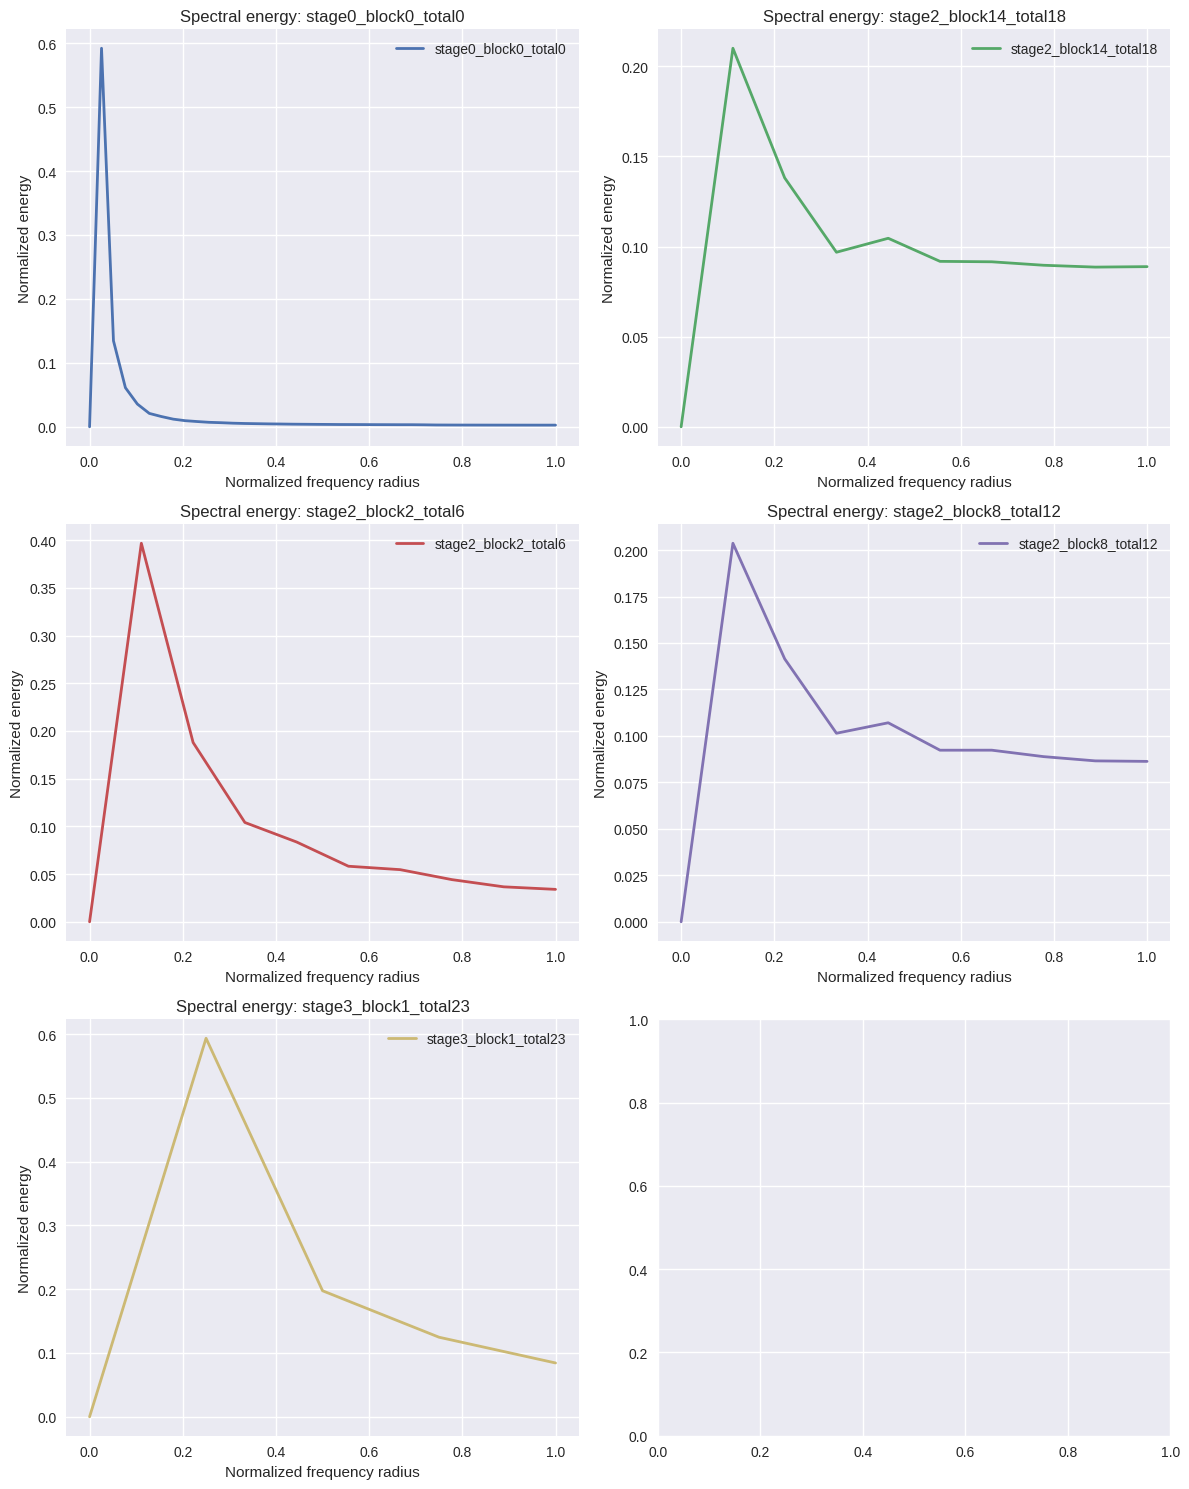

In [161]:
plot_spectra(spectra_swin_small, save_path=f"{SAVE_PATH}swin_small_imagenet_spectra.png")
np.savez(f"{SAVE_PATH}swin_small.npz", **spectra_swin_small)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


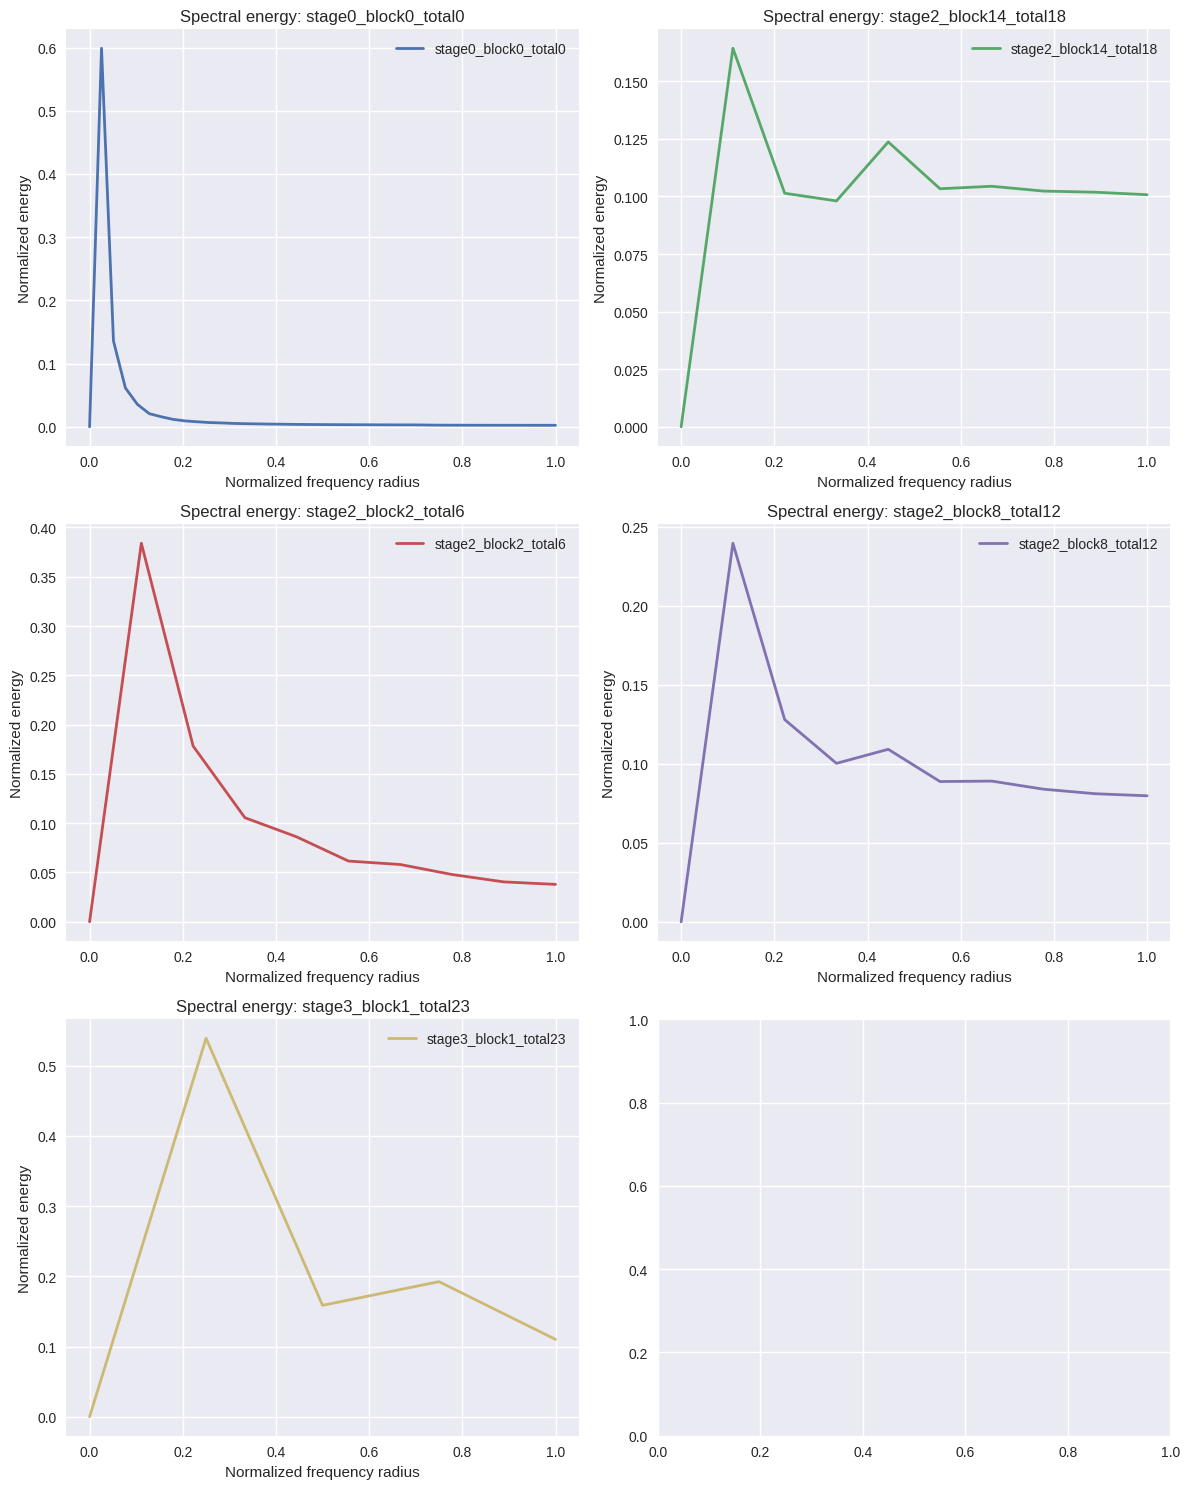

In [162]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_base_model = timm.create_model('swin_base_patch4_window7_224', pretrained=True).to(DEVICE)
base_model = HookedSwin(base_base_model).to(DEVICE)

spectra_swin_base = collect_spectra(base_model, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}swin_base.npz", **spectra_swin_base)
plot_spectra(spectra_swin_base, save_path=f"{SAVE_PATH}swin_base_imagenet_spectra.png")

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


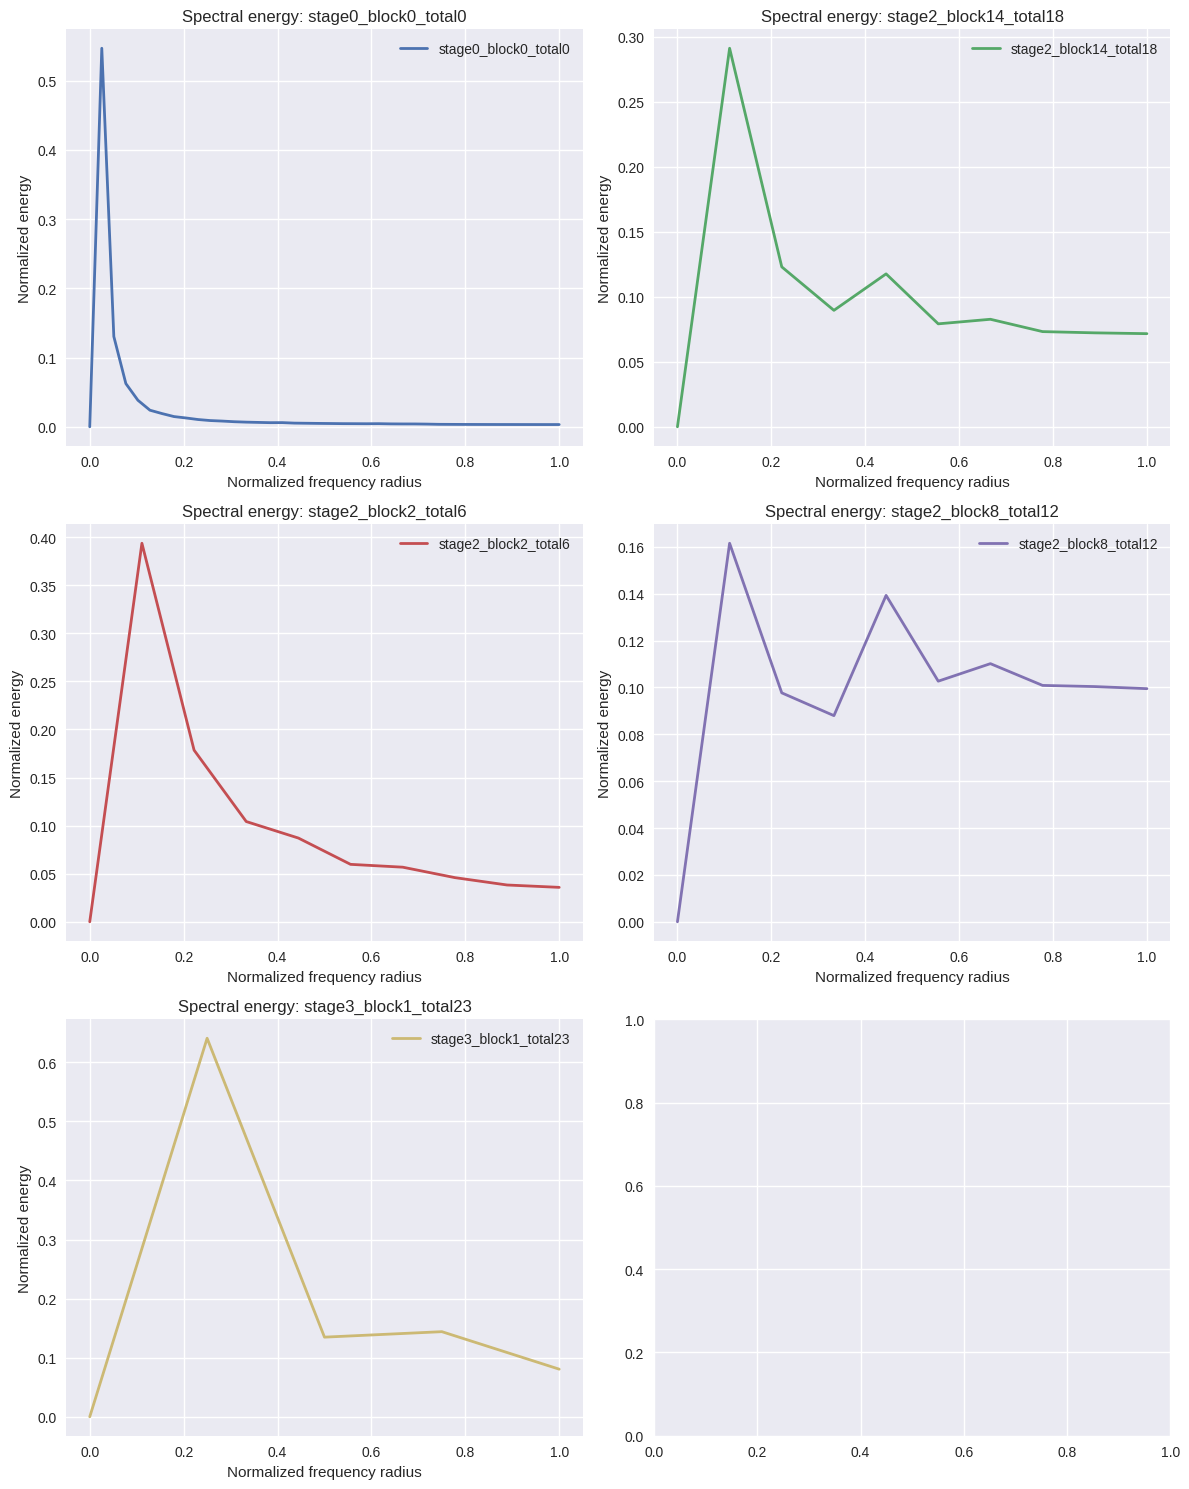

In [19]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_large_model = timm.create_model('swin_large_patch4_window7_224', pretrained=True).to(DEVICE)
large_model = HookedSwin(base_large_model).to(DEVICE)

spectra_swin_large = collect_spectra(large_model, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}swin_large.npz", **spectra_swin_large)
plot_spectra(spectra_swin_large, save_path=f"{SAVE_PATH}swin_large_imagenet_spectra.png")

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


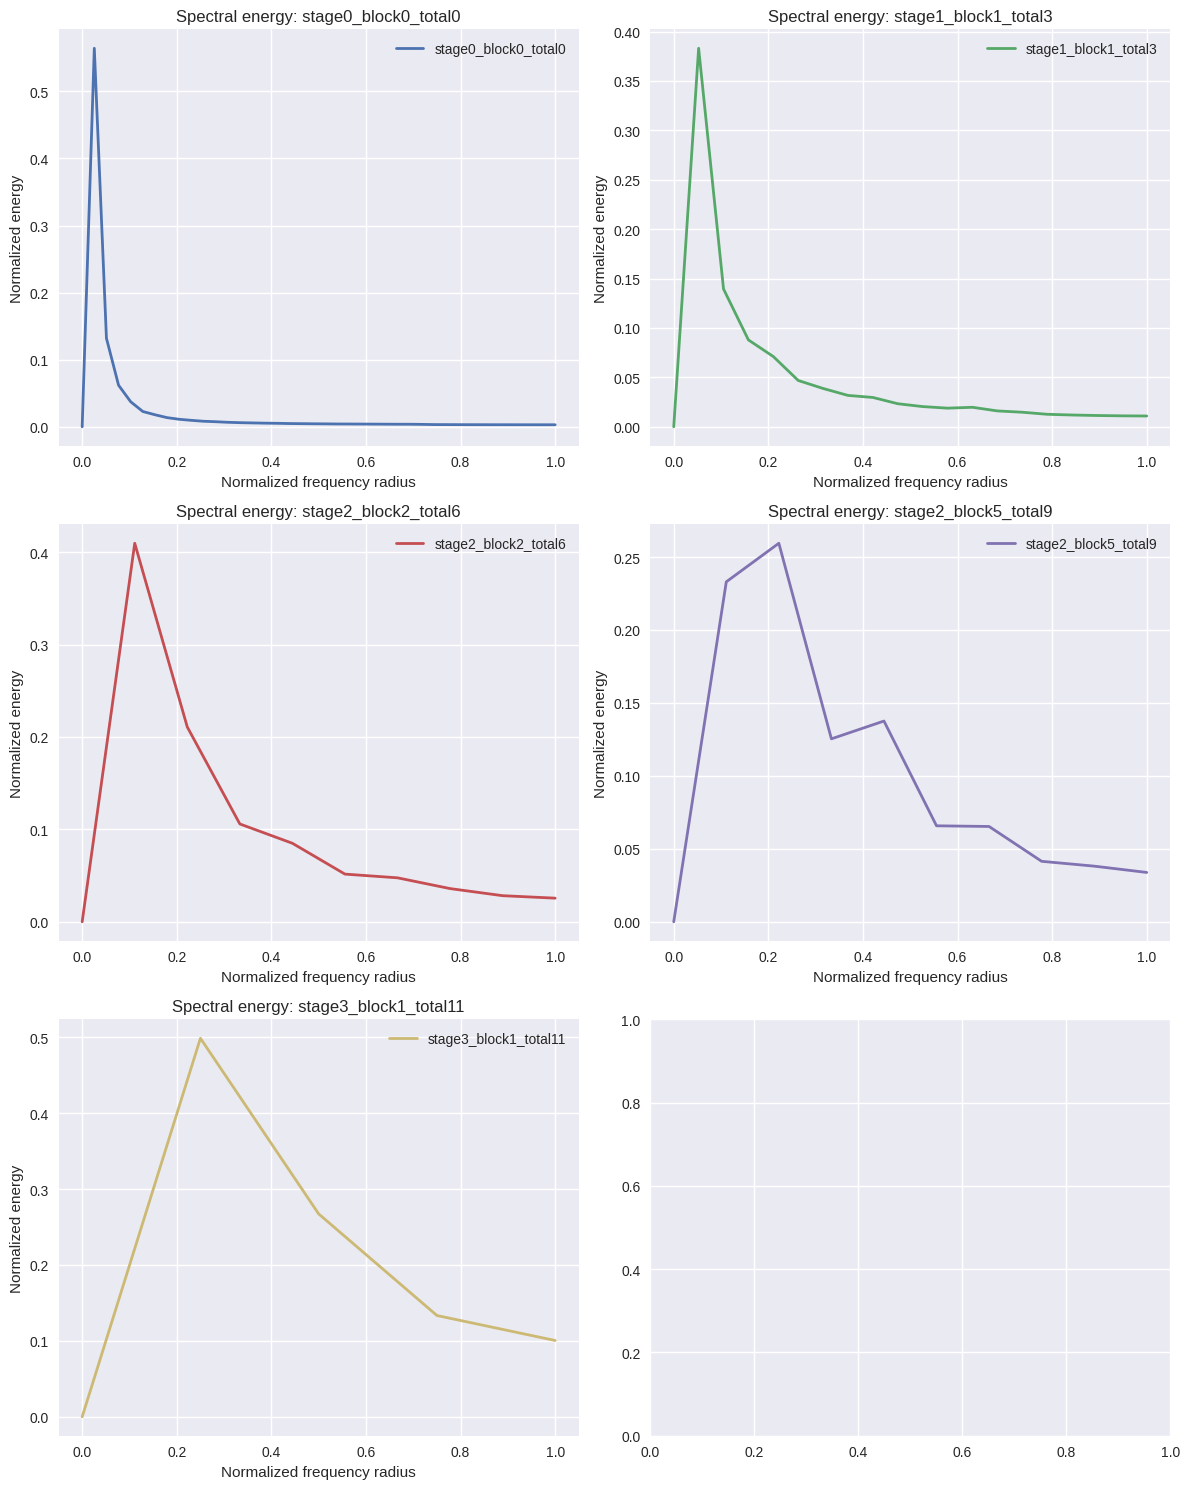

In [10]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_tiny_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True).to(DEVICE)
tiny_model = HookedSwin(base_tiny_model).to(DEVICE)

spectra_swin_tiny = collect_spectra(tiny_model, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}swin_tiny.npz", **spectra_swin_tiny)
plot_spectra(spectra_swin_tiny, save_path=f"{SAVE_PATH}swin_tiny_imagenet_spectra.png")

In [ ]:
for _ in range(60):
    os.system('echo -e "\a"')
    time.sleep(0.5)

## Все снятые слои для каждой модели

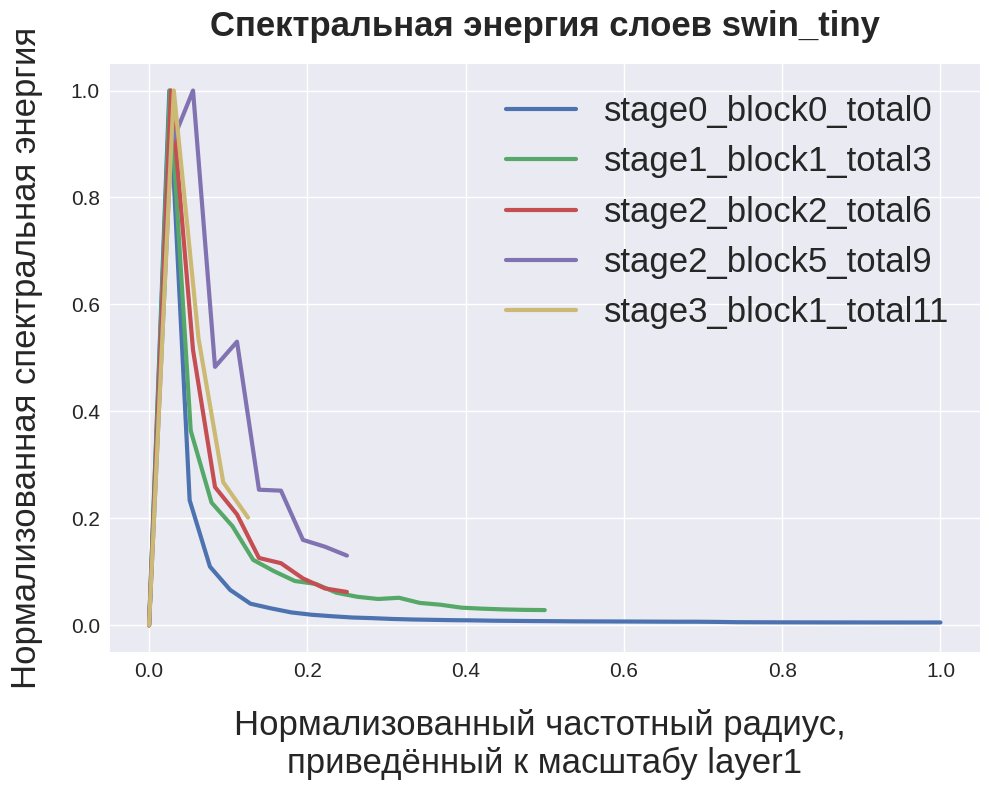

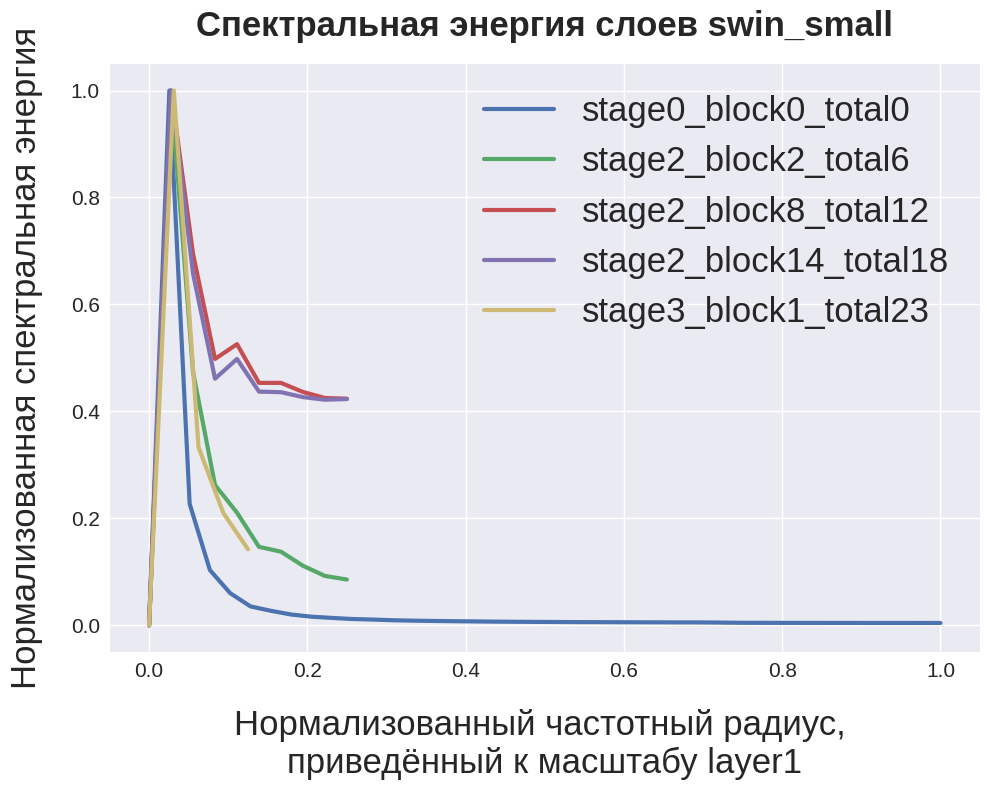

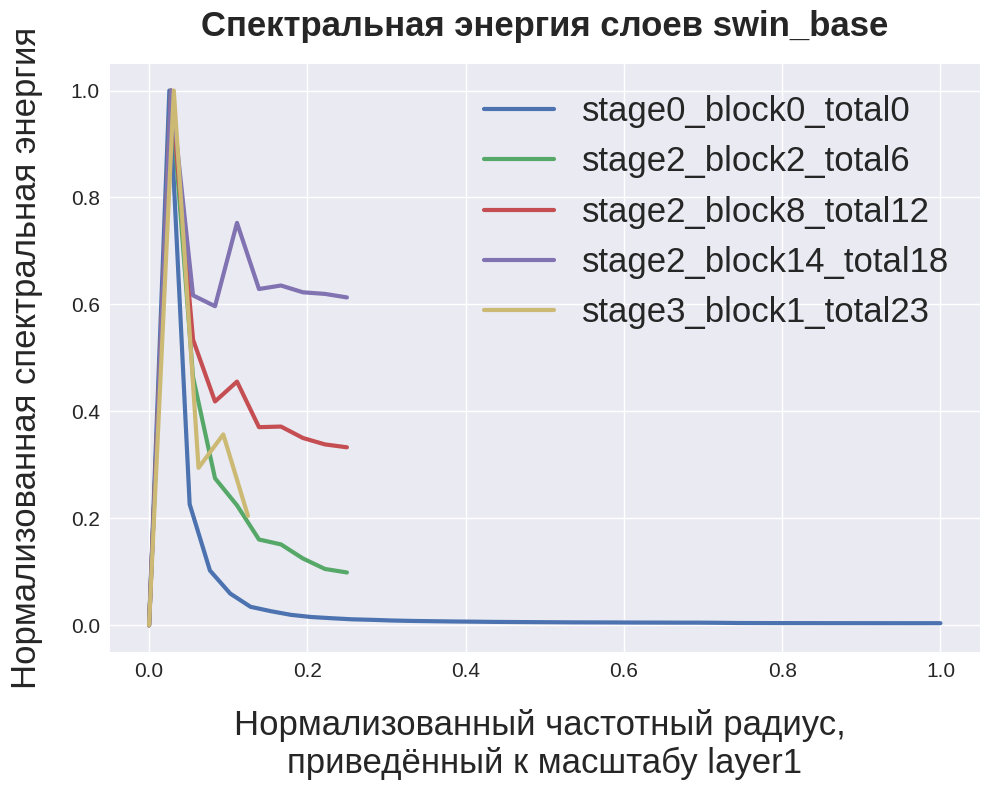

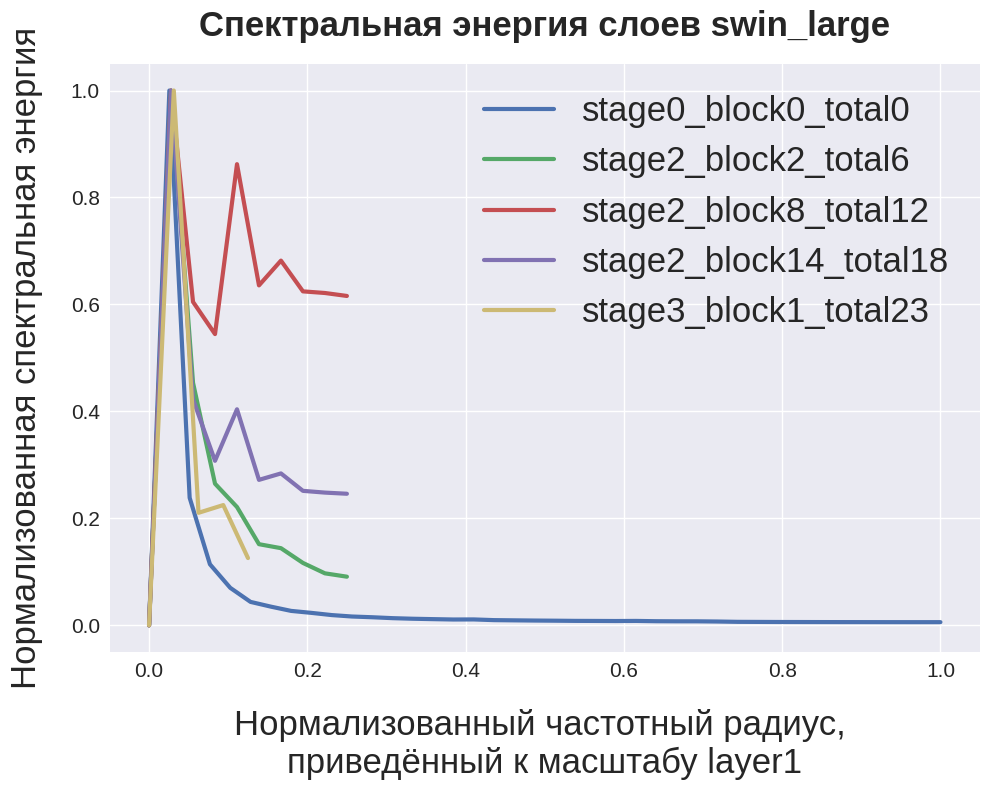

In [30]:
plot_spectra_compare("swin_tiny", spectra_swin_tiny, save_path=f"{SAVE_PATH}compare/swin_tiny.png")
plot_spectra_compare("swin_small", spectra_swin_small, save_path=f"{SAVE_PATH}compare/swin_small.png")
plot_spectra_compare("swin_base", spectra_swin_base, save_path=f"{SAVE_PATH}compare/swin_base.png")
plot_spectra_compare("swin_large", spectra_swin_large, save_path=f"{SAVE_PATH}compare/swin_large.png")

## На разных слоях как видут себя swin

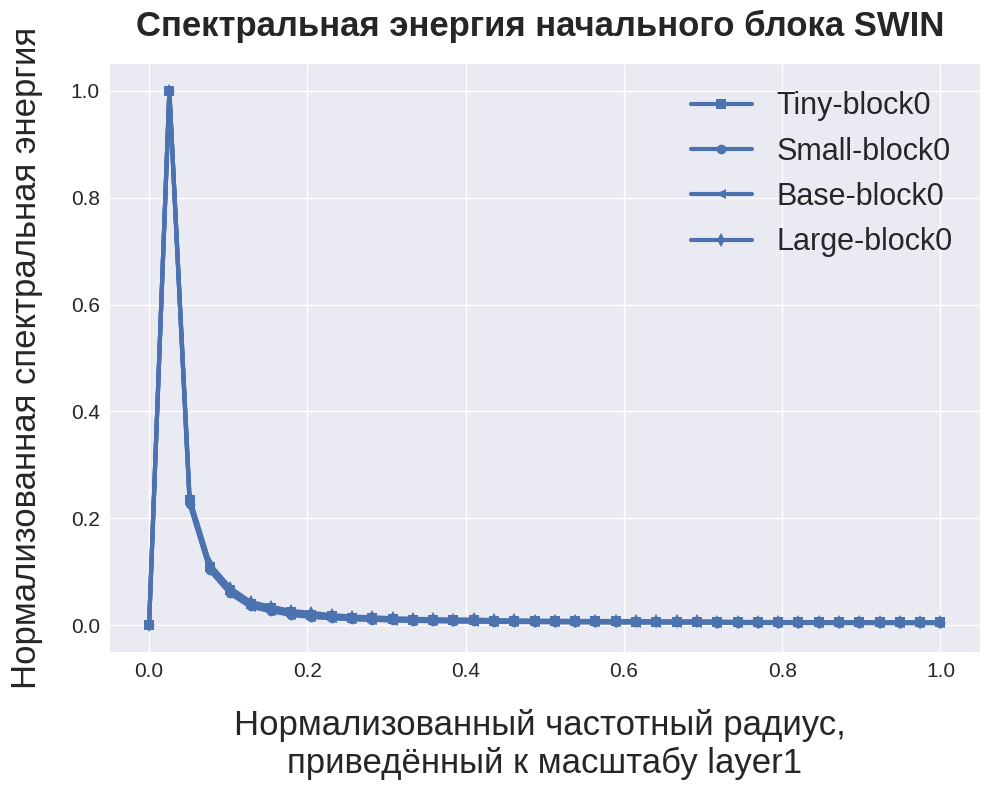

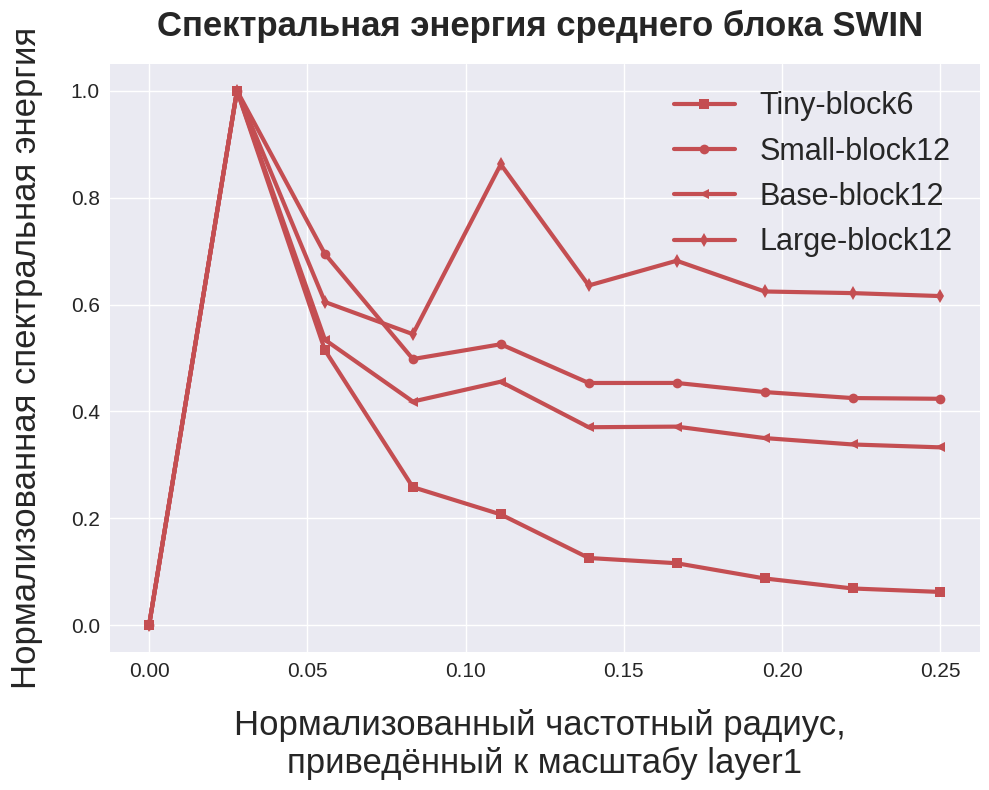

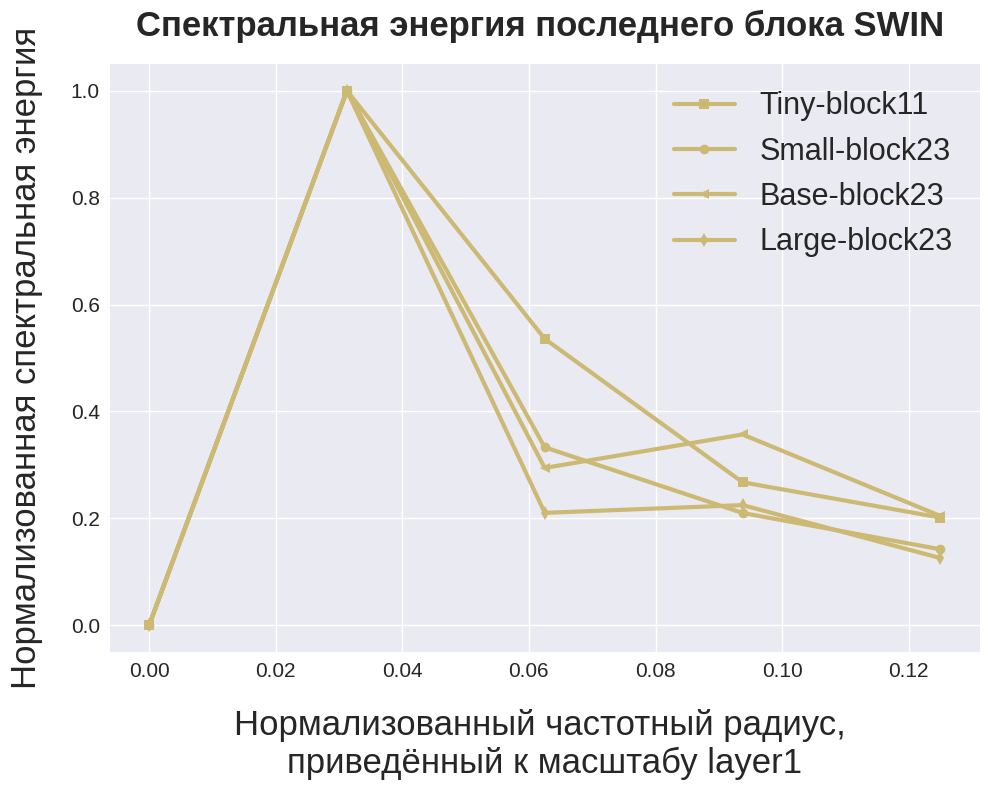

In [40]:
plot_spectra_compare_in_layer(models_dict, "начального", save_path=f"{SAVE_PATH}compare/swin_block_0.png")
plot_spectra_compare_in_layer(models_dict, "среднего", save_path=f"{SAVE_PATH}compare/swin_block_middle.png")
plot_spectra_compare_in_layer(models_dict, "последнего", save_path=f"{SAVE_PATH}compare/swin_block_last.png")

## Метрики для численного сравнения


In [60]:
resolutions = {layer: len(curve) for layer, curve in spectra_swin_tiny.items()}
metrics_swin_tiny = pd.DataFrame(compute_metrics(spectra_swin_tiny, resolutions)).T
metrics_swin_tiny.columns = ["centroid", "low_frac", "high_frac"]
metrics_swin_tiny

,centroid,low_frac,high_frac
stage0_block0_total0,0.114116,21.846261,1.760466
stage1_block1_total3,0.113473,21.069885,0.000000
stage2_block2_total6,0.073685,25.941520,0.000000
stage2_block5_total9,0.088715,25.392815,0.000000
stage3_block1_total11,0.053148,29.610975,0.000000


In [61]:
resolutions = {layer: len(curve) for layer, curve in spectra_swin_small.items()}
metrics_swin_small = pd.DataFrame(compute_metrics(spectra_swin_small, resolutions)).T
metrics_swin_small.columns = ["centroid", "low_frac", "high_frac"]
metrics_swin_small

,centroid,low_frac,high_frac
stage0_block0_total0,0.102639,22.410142,1.505797
stage2_block2_total6,0.078733,25.403919,0.000000
stage2_block8_total12,0.113787,22.184679,0.000000
stage2_block14_total18,0.113976,22.051425,0.000000
stage3_block1_total23,0.049428,29.868684,0.000000


In [62]:
resolutions = {layer: len(curve) for layer, curve in spectra_swin_base.items()}
metrics_swin_base = pd.DataFrame(compute_metrics(spectra_swin_base, resolutions)).T
metrics_swin_base.columns = ["centroid", "low_frac", "high_frac"]
metrics_swin_base

,centroid,low_frac,high_frac
stage0_block0_total0,0.098404,22.603603,1.391621
stage2_block2_total6,0.081562,25.155173,0.000000
stage2_block8_total12,0.109677,22.559503,0.000000
stage2_block14_total18,0.124675,21.245644,0.000000
stage3_block1_total23,0.053982,29.456177,0.000000


In [63]:
resolutions = {layer: len(curve) for layer, curve in spectra_swin_large.items()}
metrics_swin_large = pd.DataFrame(compute_metrics(spectra_swin_large, resolutions)).T
metrics_swin_large.columns = ["centroid", "low_frac", "high_frac"]
metrics_swin_large

,centroid,low_frac,high_frac
stage0_block0_total0,0.120913,21.501674,1.903727
stage2_block2_total6,0.080103,25.293356,0.000000
stage2_block8_total12,0.125356,21.333756,0.000000
stage2_block14_total18,0.102704,23.125970,0.000000
stage3_block1_total23,0.048444,29.929442,0.000000


In [64]:
print(compute_slope(metrics_swin_tiny["centroid"]))
print(compute_slope(metrics_swin_small["centroid"]))
print(compute_slope(metrics_swin_base["centroid"]))
print(compute_slope(metrics_swin_large["centroid"]))

0.16165432878426989
0.06911644335603308
0.04335832687805465
0.11693057624653545


In [65]:
df_result = pd.concat([metrics_swin_tiny,
                       metrics_swin_small,
                       metrics_swin_base,
                      metrics_swin_large], axis=0,
                     keys=["metrics_swin_tiny",
                           "metrics_swin_small",
                           "metrics_swin_base",
                           "metrics_swin_large"])
df_result

centroid   low_frac  high_frac
metrics_swin_tiny  stage0_block0_total0    0.114116  21.846261   1.760466
                   stage1_block1_total3    0.113473  21.069885   0.000000
                   stage2_block2_total6    0.073685  25.941520   0.000000
                   stage2_block5_total9    0.088715  25.392815   0.000000
                   stage3_block1_total11   0.053148  29.610975   0.000000
metrics_swin_small stage0_block0_total0    0.102639  22.410142   1.505797
                   stage2_block2_total6    0.078733  25.403919   0.000000
                   stage2_block8_total12   0.113787  22.184679   0.000000
                   stage2_block14_total18  0.113976  22.051425   0.000000
                   stage3_block1_total23   0.049428  29.868684   0.000000
metrics_swin_base  stage0_block0_total0    0.098404  22.603603   1.391621
                   stage2_block2_total6    0.081562  25.155173   0.000000
                   stage2_block8_total12   0.109677  22.559503   0.000000
                   stage2_block14_total18  0.124675  21.245644   0.000000
                   stage3_block1_total23   0.053982  29.456177   0.000000
metrics_swin_large stage0_block0_total0    0.120913  21.501674   1.903727
                   stage2_block2_total6    0.080103  25.293356   0.000000
                   stage2_block8_total12   0.125356  21.333756   0.000000
                   stage2_block14_total18  0.102704  23.125970   0.000000
                   stage3_block1_total23   0.048444  29.929442   0.000000

## Поиграемся с погрешностью - черновик грязь не нужен


In [4]:
# -------------------------------
# 6. Run Spectral Analysis
# -------------------------------
def collect_all_spectra(model, loader, device, max_batches):
    model.eval()
    spectra = {}
    processed = 0

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt += 1
            if cnt%40==2: print(f'{cnt} ')
            images = images.to(device)
            _ = model(images) 
            
            feats = model.get_features()        
            
            for name, feat in feats.items():
                # feat: (B, N, D)
                # Преобразуем в 2D карту (B, H, W, D)
                if feat.dim() == 4:
                    # Уже 2D: (B, H, W, D)
                    feat_2d = feat
                    H, W = feat.shape[1], feat.shape[2]
                else:
                    # 3D: (B, N, D) → преобразуем в 2D
                    resolution = model.block_resolutions[name]
                    feat_2d = model.patches_to_2d(feat, resolution)
                    H, W = resolution
                
                # Вычитаем среднее по пространству (H, W) для каждого канала
                spatial_mean = feat_2d.mean(dim=(1, 2), keepdim=True)  # (B, 1, 1, D)
                feat_centered = feat_2d - spatial_mean
                
                # Меняем форму для compute_fft_power: из (B, H, W, D) в (B, D, H, W)
                # потому что compute_fft_power ожидает (B, C, H, W)
                feat_centered = feat_centered.permute(0, 3, 1, 2)  # (B, D, H, W)
                
                # Считаем спектр (используем ту же функцию, что для ResNet)
                power_2d = compute_fft_power(feat_centered)  # (H, W)
                
                # Радиальное усреднение
                curve = radial_average(power_2d)
                spectra.setdefault(name, []).append(curve)

            if cnt >= max_batches:
                break


    return spectra

# -------------------------------
# 7. Metrics
# -------------------------------
def compute_metrics_with_uncertainty(all_spectra, resolutions, ref_layer='block_0',
                                      low_thresh=0.2, high_thresh=0.5, num_points=1000):
    ref_res = resolutions[ref_layer]
    r_common = np.linspace(0, 1, num_points)
    
    metrics_summary = {}
    all_metrics = {'centroid': {}, 'low_frac': {}, 'high_frac': {}}
    
    for layer, curves in all_spectra.items():
        centroids = []
        low_fracs = []
        high_fracs = []
        
        for curve in curves:
            # Нормализация
            curve_norm = curve / np.sum(curve)
            L = len(curve)
            r_orig = np.arange(L) / (L - 1)
            
            # Масштабирование
            scale = resolutions[layer] / ref_res
            r_mapped = r_orig * scale
            
            # Интерполяция
            interp_func = interp1d(r_mapped, curve_norm, kind='linear',
                                   bounds_error=False, fill_value=0.0)
            curve_interp = interp_func(r_common)
            
            # Центроид
            centroid = np.sum(r_common * curve_interp) / np.sum(curve_interp)
            centroids.append(centroid)
            
            # Low fraction
            low_mask = r_common < low_thresh
            low_frac = np.sum(curve_interp[low_mask])
            low_fracs.append(low_frac)
            
            # High fraction
            high_mask = r_common > high_thresh
            high_frac = np.sum(curve_interp[high_mask])
            high_fracs.append(high_frac)
        
        # Сохраняем статистику
        metrics_summary[layer] = {
            'centroid': (np.mean(centroids), np.std(centroids)),
            'low_frac': (np.mean(low_fracs), np.std(low_fracs)),
            'high_frac': (np.mean(high_fracs), np.std(high_fracs)),
            'n_samples': len(centroids)
        }
        
        all_metrics['centroid'][layer] = centroids
        all_metrics['low_frac'][layer] = low_fracs
        all_metrics['high_frac'][layer] = high_fracs
    
    return metrics_summary, all_metrics, r_common

# -------------------------------
# 7. Plotting
# -------------------------------
def plot_spectra(spectra_dict, save_path=None):
    plt.style.use("seaborn-v0_8")
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()
    blocks = ["layer1", "layer2", "layer3", "layer4"]

    for i, blk in enumerate(blocks):
        if blk in spectra_dict:
            curve = spectra_dict[blk]
            x = np.arange(len(curve)) / max(1, (len(curve) - 1))
            axs[i].plot(x, curve, label=blk, color=f"C{i}", linewidth=2, alpha=0.05)
            axs[i].set_title(f"Spectral energy: {blk}")
            axs[i].set_xlabel("Normalized frequency radius")
            axs[i].set_ylabel("Normalized energy")
            axs[i].grid(True)
            # axs[i].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# main()

In [5]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
MAX_BATCHES = 1000

base_small_model = timm.create_model('swin_small_patch4_window7_224', pretrained=True).to(DEVICE)
small_model = HookedSwin(base_small_model).to(DEVICE)

base_base_model = timm.create_model('swin_base_patch4_window7_224', pretrained=True).to(DEVICE)
base_model = HookedSwin(base_base_model).to(DEVICE)

base_large_model = timm.create_model('swin_large_patch4_window7_224', pretrained=True).to(DEVICE)
large_model = HookedSwin(base_large_model).to(DEVICE)

base_tiny_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True).to(DEVICE)
tiny_model = HookedSwin(base_tiny_model).to(DEVICE)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 71baf7ed-cf7c-4f7b-98b5-73860316fc16)')' thrown while requesting HEAD https://huggingface.co/timm/swin_small_patch4_window7_224.ms_in22k_ft_in1k/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7fb91ccf-5575-42c0-bc83-20c438fbc526)')' thrown while requesting HEAD https://huggingface.co/timm/swin_small_patch4_window7_224.ms_in22k_ft_in1k/resolve/main/model.safetensors
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: cd2a69e0-84f9-405c-a2a9-02cf46527763)')' thrown while requesting HEAD https://huggingface.co/timm/swin_small_patch4_window7_224.ms_in22k_ft_in1k/resolve/main/model.safetensors
Retrying in 4s [Retry 3/5].


In [ ]:
all_spectra_swin_small = collect_all_spectra(small_model, val_loader, DEVICE, MAX_BATCHES)

In [ ]:
all_spectra_swin_base = collect_all_spectra(base_model, val_loader, DEVICE, MAX_BATCHES)

In [ ]:
all_spectra_swin_large = collect_all_spectra(large_model, val_loader, DEVICE, MAX_BATCHES)

In [ ]:
all_spectra_swin_tiny = collect_all_spectra(tiny_model, val_loader, DEVICE, MAX_BATCHES)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 


In [ ]:
# np.savez(f"{SAVE_PATH}swin_small.npz", **all_spectra_swin_small)
# np.savez(f"{SAVE_PATH}swin_base.npz", **all_spectra_swin_base)
# np.savez(f"{SAVE_PATH}swin_large.npz", **all_spectra_swin_large)
np.savez(f"{SAVE_PATH}swin_tiny.npz", **all_spectra_swin_tiny)


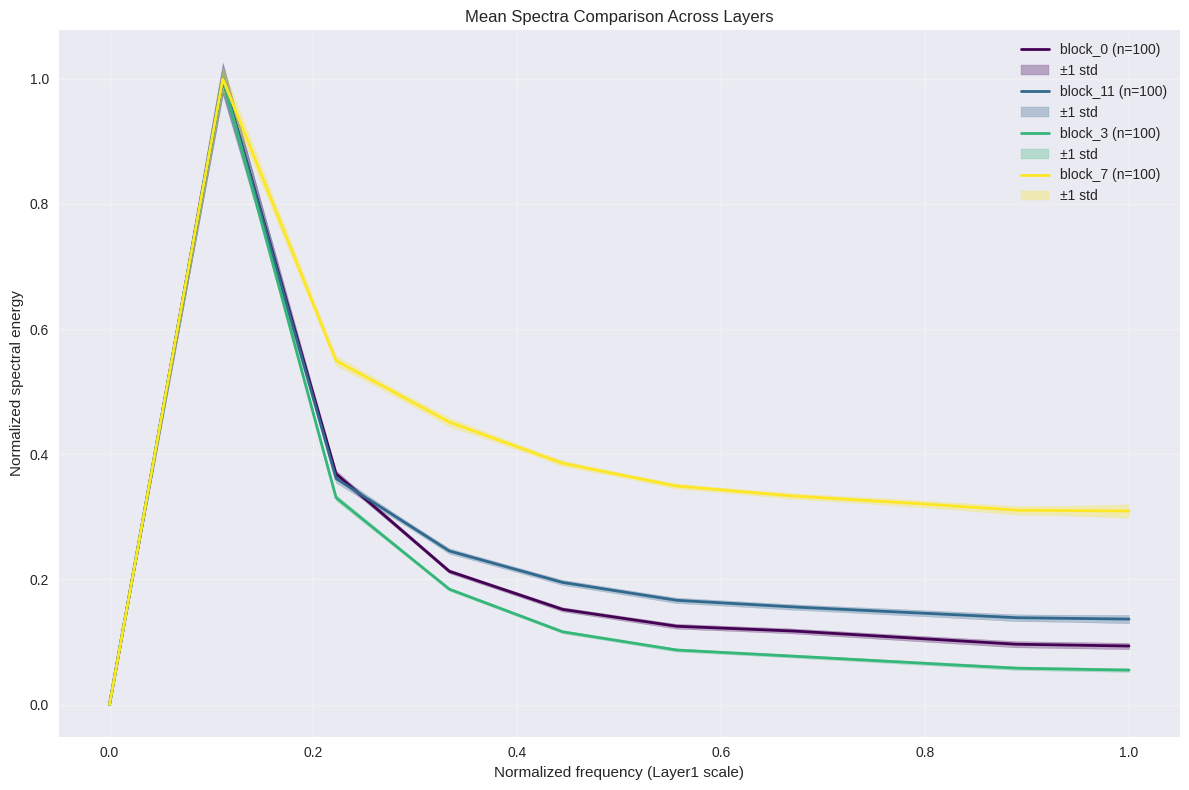

In [229]:
def interpolate_spectrum_to_common_grid(curve, resolution, ref_res, num_points=1000):
    """
    Интерполирует спектр на общую сетку частот.
    
    Параметры:
        curve: array - радиальный спектр
        resolution: int - разрешение слоя
        ref_res: int - разрешение эталонного слоя
        num_points: int - количество точек в целевой сетке
    
    Возвращает:
        r_common: array - общая сетка частот
        curve_interp: array - интерполированный спектр
    """
    # Нормализация
    curve_norm = curve / np.sum(curve)
    
    # Исходные частоты
    L = len(curve)
    r_orig = np.arange(L) / (L - 1)
    
    # Масштабирование
    scale = resolution / ref_res
    r_mapped = r_orig * scale
    
    # Целевая сетка (только до максимальной доступной частоты)
    max_freq = min(1.0, scale)  # не может быть больше 1
    r_common = np.linspace(0, max_freq, num_points)
    
    # Интерполяция
    interp_func = interp1d(r_mapped, curve_norm, kind='linear', 
                           bounds_error=False, fill_value=0.0)
    curve_interp = interp_func(r_common)
    
    return r_common, curve_interp


def prepare_spectra_for_plotting(all_spectra, resolutions, ref_layer='block_0', num_points=1000):
    """
    Подготавливает все спектры для визуализации: интерполирует на общую сетку.
    
    Возвращает:
        spectra_interp: dict {layer: {'r': array, 'curves': list_of_arrays, 'mean': array, 'std': array}}
    """
    ref_res = resolutions[ref_layer]
    spectra_interp = {}
    
    for layer, curves in all_spectra.items():
        resolution = resolutions[layer]
        
        # Интерполируем все кривые
        interp_curves = []
        r_common = None
        
        for curve in curves:
            r, curve_interp = interpolate_spectrum_to_common_grid(
                curve, resolution, ref_res, num_points
            )
            if r_common is None:
                r_common = r
            interp_curves.append(curve_interp)
        
        # Преобразуем в массив для удобства
        interp_curves = np.array(interp_curves)
        
        spectra_interp[layer] = {
            'r': r_common,
            'curves': interp_curves,
            'mean': np.mean(interp_curves, axis=0),
            'std': np.std(interp_curves, axis=0),
            'n_samples': len(interp_curves)
        }
    
    return spectra_interp


# ============================================================
# 2. Различные типы визуализации
# ============================================================

def plot_all_layers_comparison(spectra_interp, layers=None, title=None, figsize=(12, 8)):
    """
    Сравнивает средние спектры всех слоёв на одном графике.
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        layers: list - список слоёв для отображения (по умолчанию все)
        title: str - заголовок
        figsize: tuple - размер фигуры
    """
    if layers is None:
        layers = list(spectra_interp.keys())
    
    # Сортируем слои по порядку (layer1, layer2, ...)
    layers = sorted(layers)
    
    plt.figure(figsize=figsize)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(layers)))
    
    for i, layer in enumerate(layers):
        data = spectra_interp[layer]
        r = data['r']
        std = data['std']
        mean = data['mean']/data['mean'].max()
        plt.plot(r, mean, color=colors[i], linewidth=2, label=f"{layer} (n={data['n_samples']})")
        plt.fill_between(r, mean - std, mean + std, 
                     color=colors[i], alpha=0.3, label='±1 std')
    
    if title is None:
        title = "Mean Spectra Comparison Across Layers"
    plt.title(title)
    plt.xlabel("Normalized frequency (Layer1 scale)")
    plt.ylabel("Normalized spectral energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_all_layers_comparison(prepare_spectra_for_plotting(spectra, resolutions))

In [233]:
blocks = sorted(spectra.keys(), key=lambda x: int(x.split('_')[1]))
resolutions = {name: len(spectra[name]) for name in blocks}
resolutions
metrics_summary, all_metrics, r_common = compute_metrics_with_uncertainty(spectra, resolutions)

In [234]:
pd.DataFrame(metrics_summary).T

,centroid,low_frac,high_frac,n_samples
block_0,"(0.31178073768862385, 0.014128733647381606)","(53.519003564923615, 2.6185119609622696)","(24.282885803855024, 2.1167919518861154)",100
block_3,"(0.27147789387979926, 0.008521092596643267)","(60.87066775431939, 1.698006368264027)","(18.109465164211873, 1.286440855309442)",100
block_7,"(0.4274108252904565, 0.014515911767004704)","(31.927861686156458, 2.130467424268153)","(40.86470942176496, 2.178010067302622)",100
block_11,"(0.3473858060385823, 0.01549556611247222)","(47.66473045435885, 2.8883098931545734)","(29.715820245462915, 2.2668417393707943)",100
